# Film Tavsiye Sistemi - Veri Analizi (EDA)
Bu notebook'ta MovieLens veri seteni keşfediyoruz ve analiz ediyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Veriyi Yükle

In [2]:
# MovieLens 100K veri setini yükle
data_dir = r'C:\Users\Emre\OneDrive\Masaüstü\film_tavsiye_sistemi\data\raw\ml-100k\\'

# Puanlama verileri
ratings = pd.read_csv(
    data_dir + 'u.data',
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

# Film bilgileri
movie_cols = ['movie_id', 'title', 'release_date', 'video_release_date',
              'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
              'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
              'Thriller', 'War', 'Western']

movies = pd.read_csv(
    data_dir + 'u.item',
    sep='|',
    names=movie_cols,
    encoding='latin-1'
)

# Kullanıcı bilgileri
users = pd.read_csv(
    data_dir + 'u.user',
    sep='|',
    names=['user_id', 'age', 'gender', 'occupation', 'zip_code'],
    encoding='latin-1'
)

print(f"✓ Puanlamalar: {len(ratings):,} satır")
print(f"✓ Filmler: {len(movies):,} satır")
print(f"✓ Kullanıcılar: {len(users):,} satır")

✓ Puanlamalar: 100,000 satır
✓ Filmler: 1,682 satır
✓ Kullanıcılar: 943 satır


## 2. Temel İstatistikler

In [3]:
print("="*60)
print("PUANLAMA VERİLERİ")
print("="*60)
print(ratings.head())
print("\nVeri Tipleri:")
print(ratings.dtypes)
print("\nEksik Değerler:")
print(ratings.isnull().sum())
print("\nTemel İstatistikler:")
print(ratings.describe())

PUANLAMA VERİLERİ
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Veri Tipleri:
user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

Eksik Değerler:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Temel İstatistikler:
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943

In [4]:
# Benzersiz değerler
num_users = ratings['user_id'].nunique()
num_movies = ratings['movie_id'].nunique()
num_ratings = len(ratings)

print(f"Toplam Kullanıcı: {num_users:,}")
print(f"Toplam Film: {num_movies:,}")
print(f"Toplam Puanlama: {num_ratings:,}")
print(f"\nVeri Seyrekliği: {1 - (num_ratings / (num_users * num_movies)):.2%}")

Toplam Kullanıcı: 943
Toplam Film: 1,682
Toplam Puanlama: 100,000

Veri Seyrekliği: 93.70%


## 3. Puan Dağılımı Analizi

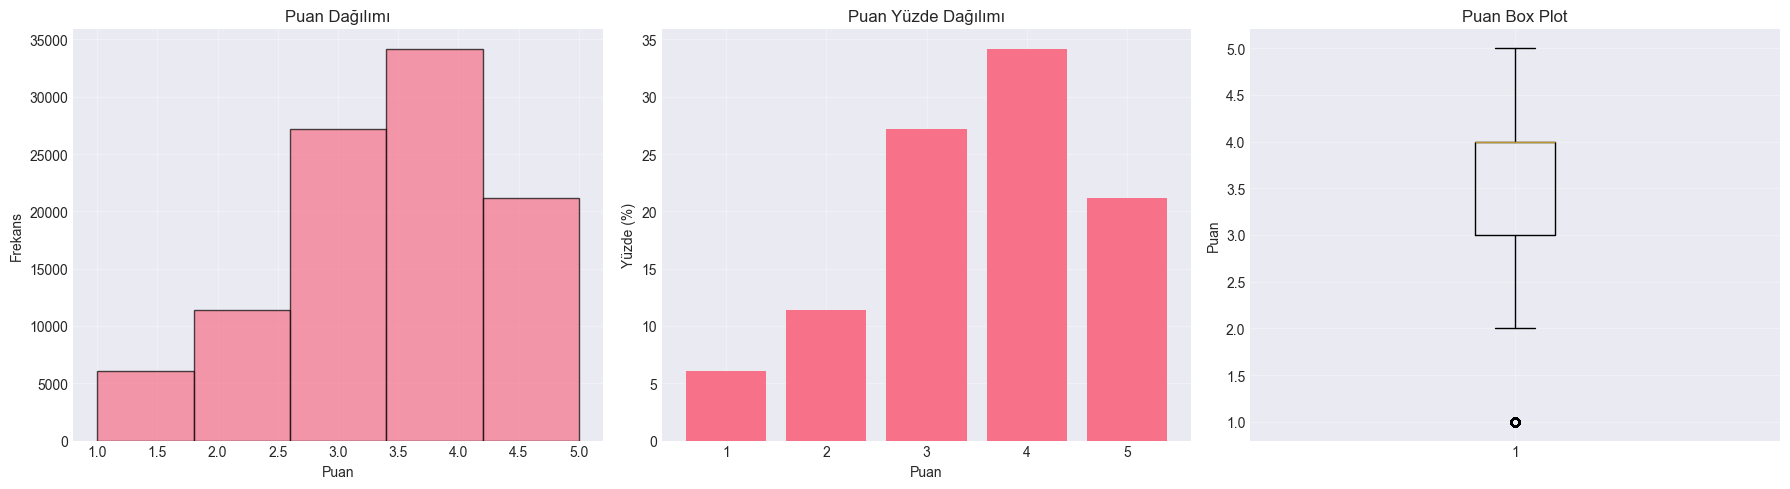

Ortalama Puan: 3.53
Medyan Puan: 4.00
Standart Sapma: 1.13


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Puan dağılımı histogram
axes[0].hist(ratings['rating'], bins=5, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Puan')
axes[0].set_ylabel('Frekans')
axes[0].set_title('Puan Dağılımı')
axes[0].grid(True, alpha=0.3)

# Puan yüzde dağılımı
rating_counts = ratings['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values / len(ratings) * 100)
axes[1].set_xlabel('Puan')
axes[1].set_ylabel('Yüzde (%)')
axes[1].set_title('Puan Yüzde Dağılımı')
axes[1].grid(True, alpha=0.3)

# Box plot
axes[2].boxplot(ratings['rating'])
axes[2].set_ylabel('Puan')
axes[2].set_title('Puan Box Plot')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ortalama Puan: {ratings['rating'].mean():.2f}")
print(f"Medyan Puan: {ratings['rating'].median():.2f}")
print(f"Standart Sapma: {ratings['rating'].std():.2f}")

## 4. Kullanıcı Analizi

Kullanıcı Başına Puanlama İstatistikleri:
Ortalama: 106.0
Medyan: 65.0
Min: 20
Max: 737


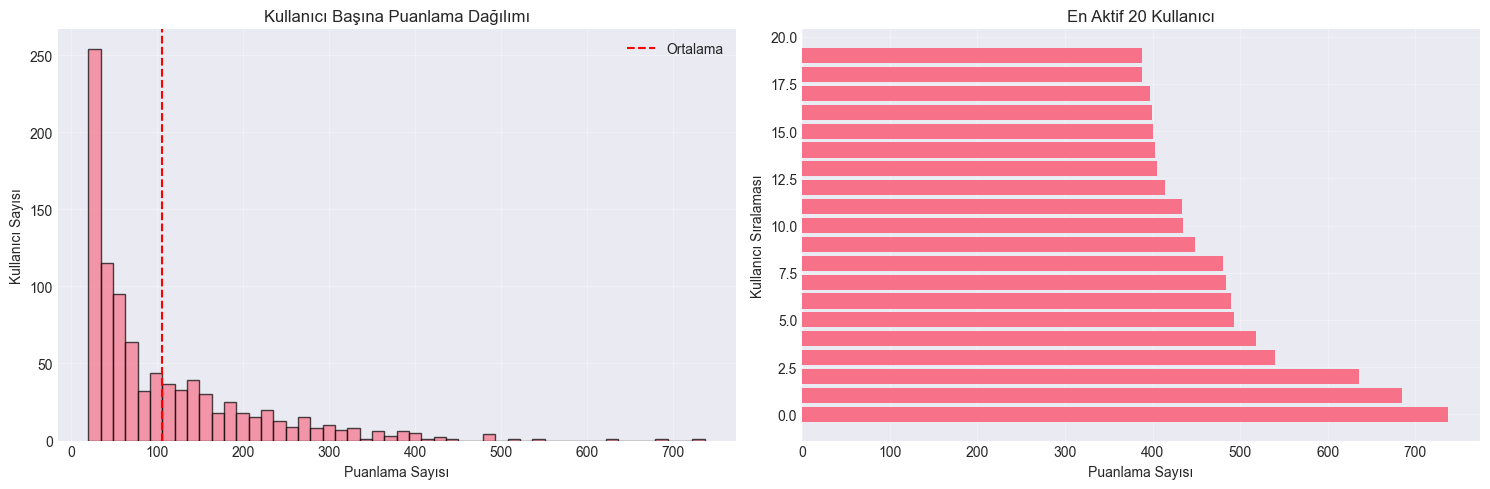

In [6]:
# Kullanıcı başına puanlama sayısı
user_rating_counts = ratings.groupby('user_id').size()

print("Kullanıcı Başına Puanlama İstatistikleri:")
print(f"Ortalama: {user_rating_counts.mean():.1f}")
print(f"Medyan: {user_rating_counts.median():.1f}")
print(f"Min: {user_rating_counts.min()}")
print(f"Max: {user_rating_counts.max()}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(user_rating_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Puanlama Sayısı')
axes[0].set_ylabel('Kullanıcı Sayısı')
axes[0].set_title('Kullanıcı Başına Puanlama Dağılımı')
axes[0].axvline(user_rating_counts.mean(), color='r', linestyle='--', label='Ortalama')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# En aktif kullanıcılar
top_users = user_rating_counts.nlargest(20)
axes[1].barh(range(len(top_users)), top_users.values)
axes[1].set_xlabel('Puanlama Sayısı')
axes[1].set_ylabel('Kullanıcı Sıralaması')
axes[1].set_title('En Aktif 20 Kullanıcı')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Film Analizi

Film Başına Puanlama İstatistikleri:
Ortalama: 59.5
Medyan: 27.0
Min: 1
Max: 583


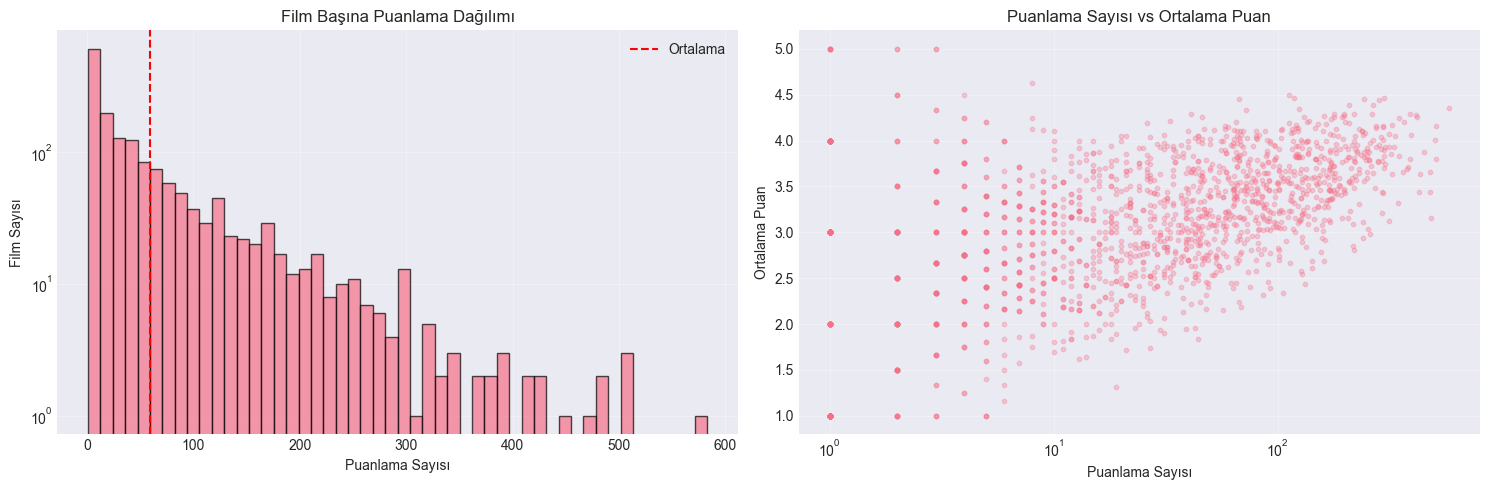

In [ ]:
# Film başına puanlama sayısı
movie_rating_counts = ratings.groupby('movie_id').size()
movie_avg_ratings = ratings.groupby('movie_id')['rating'].mean()

print("Film Başına Puanlama İstatistikleri:")
print(f"Ortalama: {movie_rating_counts.mean():.1f}")
print(f"Medyan: {movie_rating_counts.median():.1f}")
print(f"Min: {movie_rating_counts.min()}")
print(f"Max: {movie_rating_counts.max()}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(movie_rating_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Puanlama Sayısı')
axes[0].set_ylabel('Film Sayısı')
axes[0].set_title('Film Başına Puanlama Dağılımı')
axes[0].axvline(movie_rating_counts.mean(), color='r', linestyle='--', label='Ortalama')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Puanlama sayısı vs ortalama puan
axes[1].scatter(movie_rating_counts, movie_avg_ratings, alpha=0.3, s=10)
axes[1].set_xlabel('Puanlama Sayısı')
axes[1].set_ylabel('Ortalama Puan')
axes[1].set_title('Puanlama Sayısı vs Ortalama Puan')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# En popüler filmler
print("\nEn Çok Puanlanan 10 Film:")
print("="*60)

top_movies = movie_rating_counts.nlargest(10)
for rank, (movie_id, count) in enumerate(top_movies.items(), 1):
    movie_title = movies[movies['movie_id'] == movie_id]['title'].values[0]
    avg_rating = movie_avg_ratings[movie_id]
    print(f"{rank:2d}. {movie_title:50s} ({count:3d} puan, ort: {avg_rating:.2f})")


En Çok Puanlanan 10 Film:
 1. Star Wars (1977)                                   (583 puan, ort: 4.36)
 2. Contact (1997)                                     (509 puan, ort: 3.80)
 3. Fargo (1996)                                       (508 puan, ort: 4.16)
 4. Return of the Jedi (1983)                          (507 puan, ort: 4.01)
 5. Liar Liar (1997)                                   (485 puan, ort: 3.16)
 6. English Patient, The (1996)                        (481 puan, ort: 3.66)
 7. Scream (1996)                                      (478 puan, ort: 3.44)
 8. Toy Story (1995)                                   (452 puan, ort: 3.88)
 9. Air Force One (1997)                               (431 puan, ort: 3.63)
10. Independence Day (ID4) (1996)                      (429 puan, ort: 3.44)


In [ ]:
# En yüksek puanlı filmler (min 50 puanlama)
min_ratings = 50
qualified_movies = movie_rating_counts[movie_rating_counts >= min_ratings].index
top_rated = movie_avg_ratings[qualified_movies].nlargest(10)

print(f"\nEn Yüksek Puanlı 10 Film (min {min_ratings} puanlama):")
print("="*60)

for rank, (movie_id, avg_rating) in enumerate(top_rated.items(), 1):
    movie_title = movies[movies['movie_id'] == movie_id]['title'].values[0]
    count = movie_rating_counts[movie_id]
    print(f"{rank:2d}. {movie_title:50s} ({avg_rating:.2f}★, {count} puan)")

## 6. Tür Analizi

In [ ]:
# Tür sütunları
genre_columns = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 
                 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 
                 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 
                 'Thriller', 'War', 'Western']

# Her türde kaç film var
genre_counts = movies[genre_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.xlabel('Tür')
plt.ylabel('Film Sayısı')
plt.title('Türlere Göre Film Dağılımı')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Kullanıcı Demografikleri

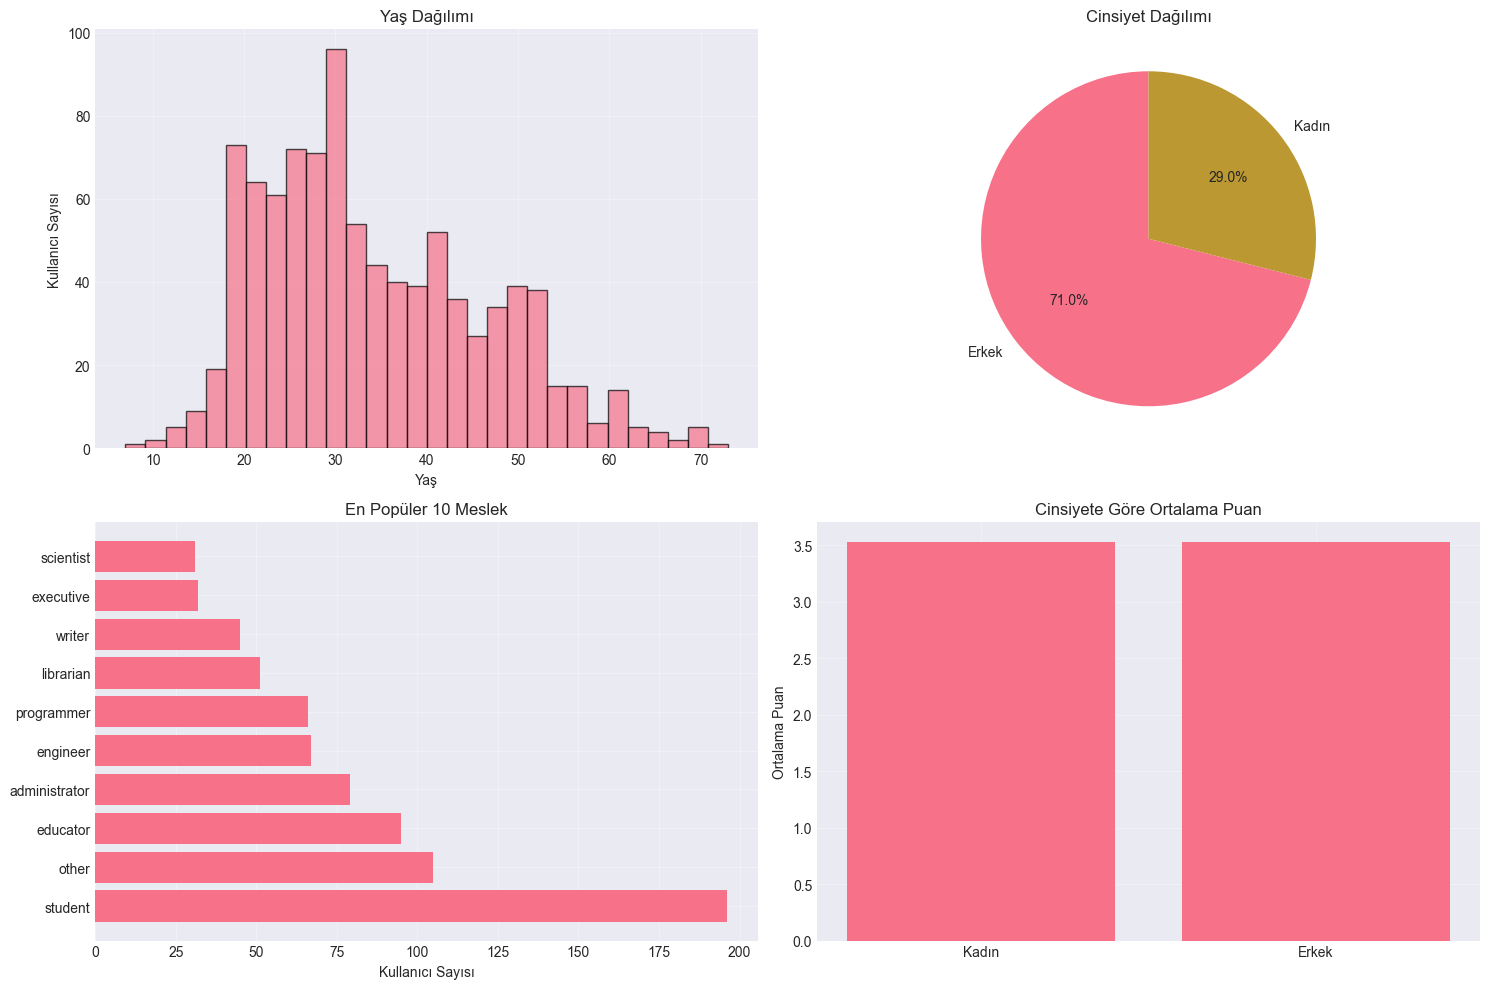

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Yaş dağılımı
axes[0, 0].hist(users['age'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Yaş')
axes[0, 0].set_ylabel('Kullanıcı Sayısı')
axes[0, 0].set_title('Yaş Dağılımı')
axes[0, 0].grid(True, alpha=0.3)

# Cinsiyet dağılımı
gender_counts = users['gender'].value_counts()
axes[0, 1].pie(gender_counts.values, labels=['Erkek' if x == 'M' else 'Kadın' for x in gender_counts.index],
               autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Cinsiyet Dağılımı')

# Meslek dağılımı (en popüler 10)
top_occupations = users['occupation'].value_counts().head(10)
axes[1, 0].barh(range(len(top_occupations)), top_occupations.values)
axes[1, 0].set_yticks(range(len(top_occupations)))
axes[1, 0].set_yticklabels(top_occupations.index)
axes[1, 0].set_xlabel('Kullanıcı Sayısı')
axes[1, 0].set_title('En Popüler 10 Meslek')
axes[1, 0].grid(True, alpha=0.3)

# Cinsiyete göre ortalama puan
ratings_with_gender = ratings.merge(users[['user_id', 'gender']], on='user_id')
gender_avg_ratings = ratings_with_gender.groupby('gender')['rating'].mean()
axes[1, 1].bar(['Kadın', 'Erkek'], [gender_avg_ratings['F'], gender_avg_ratings['M']])
axes[1, 1].set_ylabel('Ortalama Puan')
axes[1, 1].set_title('Cinsiyete Göre Ortalama Puan')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Korelasyon Analizi

In [ ]:
# Kullanıcı bazlı istatistikler
user_stats = ratings.groupby('user_id').agg({
    'rating': ['mean', 'std', 'count']
}).reset_index()
user_stats.columns = ['user_id', 'avg_rating', 'std_rating', 'num_ratings']

# Demografik bilgilerle birleştir
user_stats = user_stats.merge(users, on='user_id')

# Korelasyon matrisi
corr_data = user_stats[['age', 'avg_rating', 'std_rating', 'num_ratings']]
correlation_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Kullanıcı Özellikler Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## 9. Özet ve Bulgular

### Temel Bulgular:
1. **Veri Boyutu**: MovieLens 100K veri seti 943 kullanıcı, 1682 film ve 100,000 puanlama içeriyor.
2. **Veri Seyrekliği**: Veri matrisi oldukça seyrek (%93.7). Bu collaborative filtering yaklaşımları için tipiktir.
3. **Puan Dağılımı**: Kullanıcılar genellikle yüksek puanlar verme eğiliminde (ortalama ~3.5)
4. **Popülerlik Etkisi**: Az sayıda film çok fazla puanlama alırken, çoğu film az puanlanıyor (long-tail distribution)
5. **Kullanıcı Aktivitesi**: Kullanıcılar arasında büyük farklılıklar var (bazıları 20 film, bazıları 700+ film puanlamış)

### Model İçin Çıkarımlar:
- Seyrek veri nedeniyle embedding tabanlı yöntemler (NCF) uygun
- Popüler olmayan filmler için tahmin zor olabilir
- Kullanıcı ve film bias'larını dikkate almak önemli
- Cold start problemi için çözümler gerekebilir